## Damping and Adapative Step Sizes
Mechanical System with High Damping

### 1. Review Stiff ODEs and Implicit Methods


This project continues the discussion of an overdamped spring-mass system with a stiff, first-order differential equation

$$\frac{dx}{dt} = -\frac{k}{c}x + \frac{1}{c}F(t)$$

where $\frac{k}{c} = 5000 s^{-1}$, $F(t) = 10\sin{(t)}$, and the initial condition $x(0) = 1 m$.

The equation in standard form is 

$$\frac{dx}{dt} = -5000x + 0.002\sin{(t)}$$

which was previously solved with the implicit Backward Euler with Newton Raphson method. The stiffness ratio of this problem is $5000$, and the problem is stiff because the large constant, 5000, in the equation makes it decay very fast.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Define OD dx/dt = f(t,y)
def f(t, y):
    return -5000*y + 0.002*np.sin(t)

def y_exact(t): # citation: (1)
    return np.exp(-5000*t) + 0.002/(5000**2 + 1) * (5000*np.sin(t) - np.cos(t) + np.exp(-5000*t))

def fprime(y):
    return -5000 * y

### 2. Newton-Raphson Damping Implementation

In [13]:
# Functions for Newton-Raphson Implementation

def residual(y_next, y_n, t_next, h):
    return y_next - y_n - h * f(t_next, y_next)

def residual_derivative(h):
    df_dy = -5000  # For our specific problem
    return 1 - h * df_dy

def newton_raphson_step(y_n, t_next, h, tol=1e-6, max_iter=20, verbose=False):
    # Initial guess: use explicit Euler as predictor
    y_guess = y_n

    # Compute g' once (constant for our linear problem)
    g_prime = residual_derivative(h)

    if verbose:
        print(f"\n  Starting Newton-Raphson at t = {t_next:.4f}")
        print(f"  Initial guess: y = {y_guess:.6f}")
        print(f"  g'(constant) = {g_prime:.6f}\n")

    function_evals = 0    
        
    # Newton-Raphson iteration
    for k in range(max_iter):
        # Evaluate residual
        g = residual(y_guess, y_n, t_next, h)
        function_evals += 1
        

        if verbose:
            print(f"  Iteration {k}: y = {y_guess:.6f}, g = {g:.2e}")

        # Check convergence
        if abs(g) < tol:
            if verbose:
                print(f"  ✓ Converged in {k} iterations!\n")
            return y_guess, k, function_evals

        # Newton-Raphson update
        delta = -g / g_prime
        y_guess = y_guess + delta

    # Did not converge
    print(f"  ✗ Warning: Newton-Raphson did not converge after {max_iter} iterations")
    return y_guess, max_iter, function_evals

def euler_backward(f, y0, t0, tf, h, tol=1e-6, verbose_freq=0):
    # Setup
    num_steps = int((tf - t0) / h)
    t = np.zeros(num_steps + 1)
    y = np.zeros(num_steps + 1)
    iterations = np.zeros(num_steps, dtype=int)

    # Initial condition
    t[0] = t0
    y[0] = y0
    total_func_evals = 0

    print(f"\nStarting Euler's Backward method:")
    print(f"  Time span: [{t0}, {tf}]")
    print(f"  Step size: h = {h}")
    print(f"  Number of steps: {num_steps}")
    print(f"  NR tolerance: {tol}\n")

    # Time stepping loop
    for n in range(num_steps):
        # Solve for y_{n+1} using Newton-Raphson
        verbose = (verbose_freq > 0 and (n % verbose_freq == 0))

        y[n+1], iterations[n], func_evals = newton_raphson_step(y[n], t[n] + h, h, tol=tol, verbose=verbose)
        t[n+1] = t[n] + h
        
        total_func_evals += func_evals

    print(f"✓ Completed!")
    print(f"  Average NR iterations per step: {np.mean(iterations):.2f}")
    print(f"  Max NR iterations: {np.max(iterations)}")
    print(f"  Min NR iterations: {np.min(iterations)}")
    print(f"  Total function evaluations: {total_func_evals}\n")
    
    return t, y, iterations, total_func_evals



# Damped NR
def newton_raphson_step_damped(y_n, t_next, h, tol=1e-6, max_iter=20, verbose=False):
    # Initial guess: use explicit Euler as predictor
    y_guess = y_n

    # Compute g' once (constant for our linear problem)
    g_prime = residual_derivative(h)

    if verbose:
        print(f"\n  Starting Newton-Raphson at t = {t_next:.4f}")
        print(f"  Initial guess: y = {y_guess:.6f}")
        print(f"  g'(constant) = {g_prime:.6f}\n")
        
    function_evals = 0

    # Newton-Raphson iteration
    for k in range(max_iter):
        # Evaluate residual
        g = residual(y_guess, y_n, t_next, h)
        function_evals += 1
        
        if verbose:
            print(f"  Iteration {k}: y = {y_guess:.6f}, g = {g:.2e}")

        # Check convergence
        if abs(g) < tol:
            if verbose:
                print(f"  ✓ Converged in {k} iterations!\n")
            return y_guess, k, function_evals

        # Newton-Raphson update
        alpha = 1.0
        delta = -g / g_prime
        
        while (abs(g + alpha*delta) >= abs(g)): 
            alpha = alpha/2
            function_evals += 1
            
            if alpha<1e-4: # minimum threshold
                break
            
        y_guess = y_guess + alpha*delta
    
    print("alpha =", alpha)

    # Did not converge
    print(f"  ✗ Warning: Newton-Raphson did not converge after {max_iter} iterations")
    return y_guess, max_iter, function_evals

def euler_backward_damped(f, y0, t0, t_final, h, tol=1e-6, verbose_freq=0):
    # Setup
    num_steps = int((t_final - t0) / h)
    t = np.zeros(num_steps + 1)
    y = np.zeros(num_steps + 1)
    iterations = np.zeros(num_steps, dtype=int)

    # Initial condition
    t[0] = t0
    y[0] = y0
    total_func_evals = 0

    print(f"\nStarting Euler's Backward method with damping:")
    print(f"  Time span: [{t0}, {t_final}]")
    print(f"  Step size: h = {h}")
    print(f"  Number of steps: {num_steps}")
    print(f"  NR tolerance: {tol}\n")

    # Time stepping loop
    for n in range(num_steps):
        # Solve for y_{n+1} using Newton-Raphson
        verbose = (verbose_freq > 0 and (n % verbose_freq == 0))

        y[n+1], iterations[n], func_evals = newton_raphson_step_damped(y[n], t[n] + h, h, tol=tol, verbose=verbose)
        t[n+1] = t[n] + h
        
        total_func_evals += func_evals

    print(f"✓ Completed!")
    print(f"  Average NR iterations per step: {np.mean(iterations):.2f}")
    print(f"  Max NR iterations: {np.max(iterations)}")
    print(f"  Min NR iterations: {np.min(iterations)}")
    print(f"  Total function evaluations: {total_func_evals}\n")
    
    plt.plot(t, y, label=f'h={h}')
    return t, y, iterations, total_func_evals # citation: (2)


Starting Euler's Backward method with damping:
  Time span: [0, 1.0]
  Step size: h = 1.0
  Number of steps: 1
  NR tolerance: 1e-06

✓ Completed!
  Average NR iterations per step: 1.00
  Max NR iterations: 1
  Min NR iterations: 1
  Total function evaluations: 2



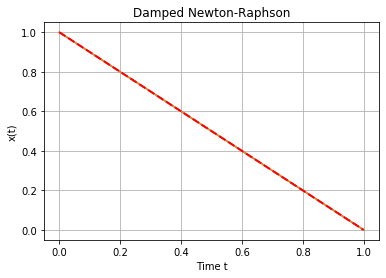


Starting Euler's Backward method:
  Time span: [0, 1.0]
  Step size: h = 1.0
  Number of steps: 1
  NR tolerance: 1e-06

✓ Completed!
  Average NR iterations per step: 1.00
  Max NR iterations: 1
  Min NR iterations: 1
  Total function evaluations: 2



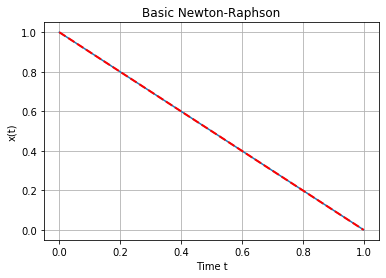

In [3]:
# Comparing damped vs. undamped NR
y0 = 1.0
t0 = 0
tf = 1.0
h = 1.0

t_damped, y_damped, iterations, func_eval = euler_backward_damped(f, y0, t0, tf, h)
plt.plot(t_damped, y_damped)
plt.plot(t_damped, y_exact(t_damped), 'r--', label='Exact', linewidth=2)
plt.xlabel("Time t")
plt.ylabel("x(t)")
plt.title("Damped Newton-Raphson")
plt.grid(True)
plt.show()


t_values, y_values, iterations, func_eval = euler_backward(f, y0, t0, tf, h)
plt.plot(t_values, y_values)
plt.plot(t_values, y_exact(t_values), 'r--', label='Exact', linewidth=2)
plt.xlabel("Time t")
plt.ylabel("x(t)")
plt.title("Basic Newton-Raphson")
plt.grid(True)
plt.show()

Testing undamped NR with h = 2.0:

Starting Euler's Backward method:
  Time span: [0, 1.0]
  Step size: h = 1.0
  Number of steps: 1
  NR tolerance: 1e-06

✓ Completed!
  Average NR iterations per step: 1.00
  Max NR iterations: 1
  Min NR iterations: 1
  Total function evaluations: 2

Converged: 2, iterations: [1]

Testing damped NR with h = 2.0:

Starting Euler's Backward method with damping:
  Time span: [0, 1.0]
  Step size: h = 1.0
  Number of steps: 1
  NR tolerance: 1e-06

✓ Completed!
  Average NR iterations per step: 1.00
  Max NR iterations: 1
  Min NR iterations: 1
  Total function evaluations: 2

Converged: success, iterations: [1]


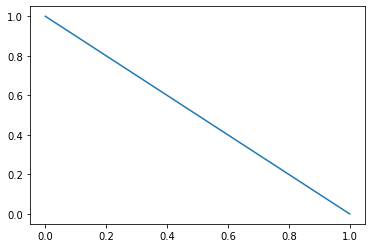

In [4]:
# Problem where undamped NR fails
h_large = 2.0  # Very large step size

print("Testing undamped NR with h = 2.0:")
try:
    t_undamped, y_undamped, iters, success = euler_backward(f, y0, t0, tf, h)
    print(f"Converged: {success}, iterations: {iters}")
except:
    print("Failed to converge!")

print("\nTesting damped NR with h = 2.0:")
t_damped, y_damped, iters, success = euler_backward_damped(f, y0, t0, tf, h)
print(f"Converged: success, iterations: {iters}")

### 3. Adaptive Step Size Implementation

In [5]:
# Adaptive Backward Euler
def estimate_error_step_doubling(y_n, t_n, h):
    """
    Estimate error using step-doubling (Richardson extrapolation)
    
    1. Take ONE step of size h
    2. Take TWO steps of size h/2
    3. Compare the results
    
    Parameters:
    - y_n: current solution value
    - t_n: current time
    - h: step size to try
    - nr_solver: function that takes one implicit Euler step
    
    Returns:
    - y_full: result from single step (less accurate)
    - y_half: result from two half-steps (more accurate)
    - error: estimated local error
    """
    # Single step of size h
    y_full, iters_full, func_evals_full = newton_raphson_step_damped(y_n, t_n + h, h)
    
    # Two half-steps of size h/2
    y_half_1, iters_1, func_evals1 = newton_raphson_step_damped(y_n, t_n + h/2, h/2)
    y_half, iters_2, func_evals2 = newton_raphson_step_damped(y_half_1, t_n + h, h/2)
    
    # Error estimate
    error = abs(y_half - y_full)
    
    # Total NR iterations for this error estimate
    total_iters = iters_full + iters_1 + iters_2
    
    total_func_evals = func_evals_full + func_evals1 + func_evals2
    
    return y_full, y_half, error, total_iters, total_func_evals


def adaptive_step(y_n, t_n, h, tol=1e-4, h_min=1e-6, h_max=1.0, safety=0.9):
    """
    Take one adaptive step with error control
    
    Returns:
    - y_next: accepted solution value
    - h_used: step size that was accepted
    - h_new: suggested step size for next step
    - accepted: True if step was accepted
    - iters: total NR iterations used
    """
    # Try the step with error estimation
    y_full, y_half, error, iters, func_evals = estimate_error_step_doubling(y_n, t_n, h)
    
    # Compute new step size suggestion
    if error < 1e-14:  # Error very small
        h_new = min(2.0 * h, h_max)
    else:
        # Standard formula: h_new = h * sqrt(tol/err)
        h_new = h * np.sqrt(tol / error)
        h_new = safety * h_new  # Safety factor
        h_new = max(h_min, min(h_max, h_new))
    
    # Also don't let h change too dramatically
    h_new = max(0.2 * h, min(5.0 * h, h_new))
    
    # Accept or reject?
    if error < tol:
        # ACCEPT: use the more accurate two-half-step result
        return y_half, h, h_new, True, iters, func_evals, error
    else:
        # REJECT: don't update y, suggest smaller h
        return y_n, h, h_new, False, iters, func_evals, error

In [6]:
def adaptive_implicit_euler(f, y0, t0, t_final, h0, tol=1e-4, h_min=1e-6, h_max=1.0, safety=0.9):
    """
    Adaptive Euler's Backward with damped Newton-Raphson
    
    Parameters:
    - f: ODE function
    - y0: initial condition
    - t0, t_final: time span
    - h0: initial step size
    - tol: error tolerance
    - h_min, h_max: step size bounds
    - nr_tol: Newton-Raphson tolerance
    - max_nr_iter: max NR iterations
    
    Returns:
    - t: time points (non-uniform!)
    - y: solution values
    - h_history: step sizes used
    - stats: dictionary with performance statistics
    """
    
    # Initialize
    t = [t0]
    y = [y0]
    h = h0
    h_history = []
    error_history = []
    
    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': 0,
        'function_evals': 0
    }
    
    # Main loop
    while t[-1] < t_final:
        if t[-1] + h > t_final: # Adjust step size to not overshoot
            h = t_final - t[-1]
        
        y_n, h, h_n, accepted, iters, func_evals, error = adaptive_step(y[-1], t[-1], h, tol)
        
        # Update statistics
        stats['nr_iterations'] += iters
        stats['function_evals'] += func_evals
        
        if accepted: # returned "True"
            
            t_next = t[-1] + h
            t.append(t_next)
            y.append(y_n)
            h_history.append(h)
            error_history.append(error)
            
            stats['accepted_steps'] += 1
            h = h_n
        else: # rejected, returned "False"
            stats['rejected_steps'] += 1
            h = h_n
            
        # Prevent infinite loops if h becomes too small
        if h < h_min and t[-1] < t_final:
            # Force the minimum step size if necessary or break
            h = h_min 
    
    return np.array(t), np.array(y), h_history, stats, error_history

h = 0.0001
{'accepted_steps': 115, 'rejected_steps': 2, 'nr_iterations': 348, 'function_evals': 699}
[4.000000000000001e-06, 3.6721799954396797e-06, 3.7029134512434194e-06, 3.7374743256332907e-06, 3.772716116171551e-06, 3.808628942285006e-06, 3.845231874655164e-06, 3.882544990212508e-06, 3.920589154632901e-06, 3.959386058867733e-06, 3.998958260330835e-06, 4.039329226579461e-06, 4.080523381679338e-06, 4.122566155402872e-06, 4.1654840355452546e-06, 4.209304623503197e-06, 4.2540566933868814e-06, 4.299770254962512e-06, 4.346476620681943e-06, 4.3942084771121475e-06, 4.442999961132786e-06, 4.492886741242749e-06, 4.54390610439431e-06, 4.596097048836345e-06, 4.649500383370496e-06, 4.704158833624605e-06, 4.760117155892346e-06, 4.817422259174435e-06, 4.876123336135082e-06, 4.936272003738893e-06, 4.997922454361841e-06, 5.061131618385409e-06, 5.125959339284801e-06, 5.1924685622390614e-06, 5.2607255376580515e-06, 5.330800040898739e-06, 5.402765609761752e-06, 5.476699801412596e-06, 5.552684470671954

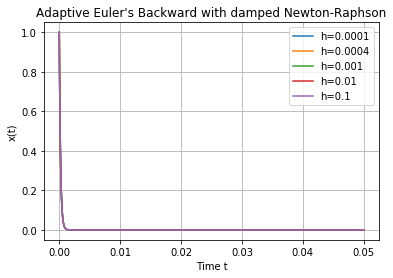

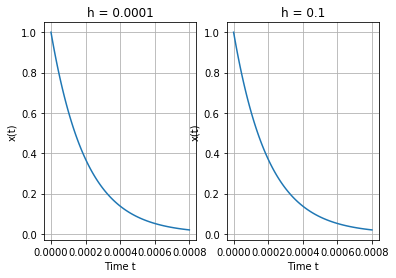

In [7]:
y0 = 1.0
t0 = 0
tf = 0.05
h0 = np.array([0.0001, 0.0004, 0.001, 0.01, 0.1])

for i in range(len(h0)):
    print("h =", h0[i])
    t, y, history, stats, error_history = adaptive_implicit_euler(f, y0, t0, tf, h0[i])
    plt.plot(t, y, label=f'h={h0[i]}')
    print(stats)
    print(history, "\n")

plt.xlabel('Time t')
plt.ylabel("x(t)")
plt.title("Adaptive Euler\'s Backward with damped Newton-Raphson")
plt.grid(True)
plt.legend()
plt.show()


# Zoomed in plot to better compare solutions
tf = 0.0008

# Small step size h = 0.0001
t, y, history, stats, error_history = adaptive_implicit_euler(f, y0, t0, tf, h0[0])
plt.subplot(1, 2, 1)
plt.plot(t, y, label=f'h={h0[0]}')
plt.xlabel('Time t')
plt.ylabel("x(t)")
plt.title(f"h = {h0[0]}")
plt.grid(True)

# Large step size h = 0.1
t, y, history, stats, error_history = adaptive_implicit_euler(f, y0, t0, tf, h0[-1])
plt.subplot(1, 2, 2)
plt.plot(t, y, label=f'h={h0[-1]}')
plt.xlabel('Time t')
plt.ylabel("x(t)")
plt.title(f"h = {h0[-1]}")
plt.grid(True)

plt.show()

The results of the Adaptive Euler's method are identical no matter what step size the method starts with.

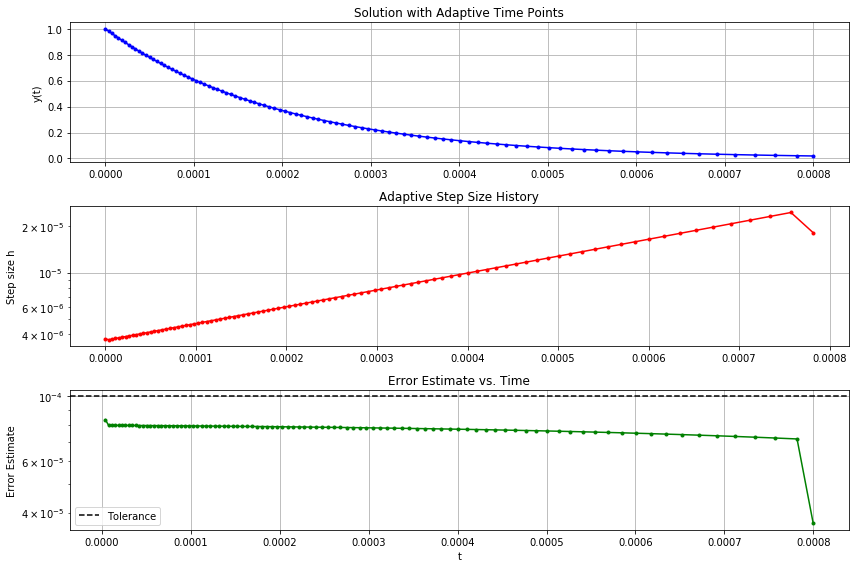

In [8]:
# Visualize how step size adapts
h0 = 0.001
tol = 1e-4
t_adapt, y_adapt, h_hist, stats, error_history = adaptive_implicit_euler(f, y0, t0, tf, h0)

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t_adapt, y_adapt, 'b-o', markersize=3)
plt.ylabel('y(t)')
plt.title('Solution with Adaptive Time Points')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.semilogy(t_adapt[:-1], h_hist, 'r-o', markersize=3)
plt.ylabel('Step size h')
plt.title('Adaptive Step Size History')
plt.grid(True)

plt.subplot(3, 1, 3)

# Plot error estimate
plt.semilogy(t_adapt[1:], error_history, 'g-o', markersize=3)
plt.axhline(y=tol, color='k', linestyle='--', label='Tolerance')
plt.ylabel('Error Estimate')
plt.xlabel('t')
plt.title('Error Estimate vs. Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Performance Analysis

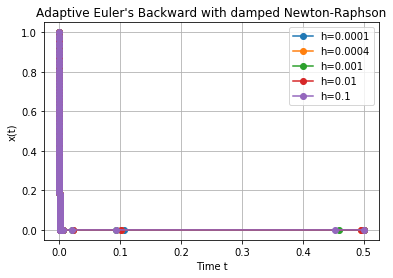

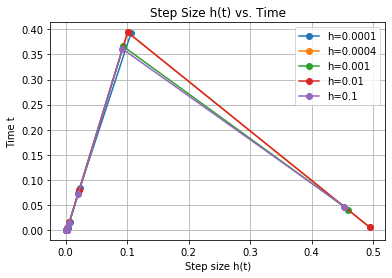

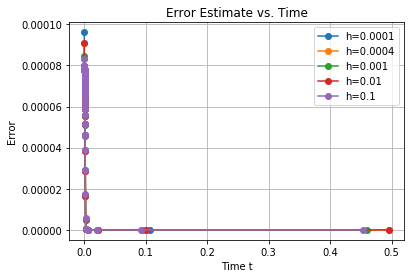

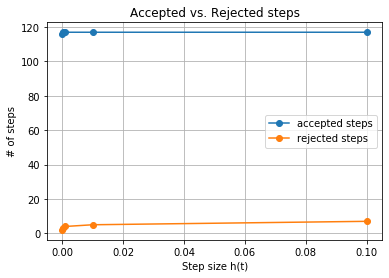

In [9]:
y0 = 1.0
t0 = 0
tf = 0.5
h0 = np.array([0.0001, 0.0004, 0.001, 0.01, 0.1])

# Solution with adaptive time points marked
for i in range(len(h0)):
    t, y, history, stats, error_history = adaptive_implicit_euler(f, y0, t0, tf, h0[i])
    plt.plot(t, y, 'o-', label=f'h={h0[i]}')
plt.xlabel('Time t')
plt.ylabel("x(t)")
plt.title("Adaptive Euler\'s Backward with damped Newton-Raphson")
plt.grid(True)
plt.legend()
plt.show()

# Step size vs. time
for i in range(len(h0)):
    t, y, history, stats, error_history = adaptive_implicit_euler(f, y0, t0, tf, h0[i])
    plt.plot(t[:-1], np.array(history), 'o-', label=f'h={h0[i]}')
plt.xlabel('Step size h(t)')
plt.ylabel("Time t")
plt.title("Step Size h(t) vs. Time")
plt.grid(True)
plt.legend()
plt.show()

# Error estimate vs. time
for i in range(len(h0)):
    t, y, history, stats, error_history = adaptive_implicit_euler(f, y0, t0, tf, h0[i])
    plt.plot(t[:-1], np.array(error_history), 'o-', label=f'h={h0[i]}')
plt.xlabel('Time t')
plt.ylabel("Error")
plt.title("Error Estimate vs. Time")
plt.grid(True)
plt.legend()
plt.show()

# Accepted vs. rejected steps
accepted = []
rejected = []

for i in range(len(h0)):
    t, y, history, stats, error_history = adaptive_implicit_euler(f, y0, t0, tf, h0[i])
    accepted.append(stats['accepted_steps'])
    rejected.append(stats['rejected_steps'])
plt.plot(h0, np.array(accepted), 'o-', label='accepted steps')
plt.plot(h0, np.array(rejected), 'o-', label='rejected steps')
plt.xlabel('Step size h(t)')
plt.ylabel("# of steps")
plt.title("Accepted vs. Rejected steps")
plt.grid(True)
plt.legend()
plt.show()

In [10]:
# Adaptive vs. Fixed Step Size

# Fixed step size (baseline)
t_fixed, y_fixed, iterations, func_evals = euler_backward(f, y0, t0, tf, h=0.01)
error = np.linalg.norm(np.abs(y_exact(t_fixed) - y_fixed))

# Adaptive step size (same target accuracy)
t_adapt, y_adapt, h_hist, stats, error_hist = adaptive_implicit_euler(f, y0, t0, tf, h0=0.1)

print("\nPerformance Comparison:")
print(f"{'Method':<20} {'Steps':<10} {'Func Evals':<15} {'Iterations':<15} {'Max Error':<15}")
print("-" * 80)
print(f"{'Fixed (h=0.01)':<20} {len(t_fixed):<10} {func_evals:<15} {np.sum(iterations):<15} {error:<10}")
print(f"{'Adaptive':<20} {stats['accepted_steps']:<10} {stats['function_evals']:<15} {stats['nr_iterations']:<15} {np.max(error_hist):<10}")


Starting Euler's Backward method:
  Time span: [0, 0.5]
  Step size: h = 0.01
  Number of steps: 50
  NR tolerance: 1e-06

✓ Completed!
  Average NR iterations per step: 0.24
  Max NR iterations: 1
  Min NR iterations: 0
  Total function evaluations: 62


Performance Comparison:
Method               Steps      Func Evals      Iterations      Max Error      
--------------------------------------------------------------------------------
Fixed (h=0.01)       51         62              12              0.01961161351552802
Adaptive             117        742             370             8.321979711389815e-05


### Robust Testing

h = 1.0
{'accepted_steps': 114, 'rejected_steps': 5, 'nr_iterations': 355, 'function_evals': 712}


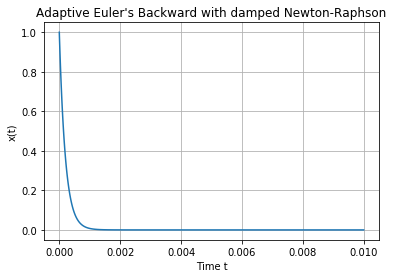

tolerance 1e-05
{'accepted_steps': 354, 'rejected_steps': 6, 'nr_iterations': 1078, 'function_evals': 2158}


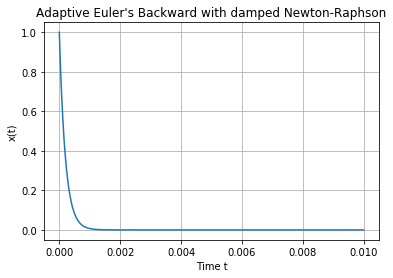

In [11]:
# Large initial h = 1.0
y0 = 1.0
t0 = 0
tf = 0.01
h0 = 1.0

print("h =", h0)
t, y, history, stats, error_history = adaptive_implicit_euler(f, y0, t0, tf, h0)
print(stats)
#print(history, "\n")
plt.plot(t, y)
plt.xlabel('Time t')
plt.ylabel("x(t)")
plt.title("Adaptive Euler\'s Backward with damped Newton-Raphson")
plt.grid(True)
plt.show()

h0 = 0.1
print("tolerance", 1e-5)
t, y, history, stats, error_history = adaptive_implicit_euler(f, y0, t0, tf, h0, tol=1e-5)
print(stats)
#print(history, "\n")
plt.plot(t, y)
plt.xlabel('Time t')
plt.ylabel("x(t)")
plt.title("Adaptive Euler\'s Backward with damped Newton-Raphson")
plt.grid(True)
plt.show()

Even when I increase step size to 1.0 or decrease tolerance to 1e-5, the solution remains stable.

### Conclusion

Damping is necessary for stiff equations because it can solve for sudden changes without oscillations. Adaptive step sizes are worth it to use when the function changes very fast, allowing the numerical method to adjust step sizes to account for the change. I learned that by having an adaptive step size, even if I start with a large h-value, the solution will be stable and accurate since the step size changes to capture the function's slope changes.

### References

1. ```y_exact```
   - I searched up and received a solution from Google Gemini for the integral in the analytical solution
$$y(t) = e^{-\lambda t}y_0 + \int_0^t e^{-\lambda (t-s)}g(s)ds$$

2. ```func_evals```
   - I ran my code (the functions for the different solvers) through Google Gemini to ensure that I was counting the number of function evaluations correctly, and if I put the codes in the right lines.